#  Disease Predictor — Neural Network + NLP


In [ ]:
# ── STEP 1: Install dependencies ───────────────────────────────────────────
!pip install -q tensorflow scikit-learn pandas numpy fuzzywuzzy python-Levenshtein
print('Dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 38.0 MB/s eta 0:00:00
Dependencies installed ✅


In [ ]:
# ── STEP 2: Upload dataset ─────────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()   # upload cleaned_dataset.csv

Saving cleaned_dataset.csv to cleaned_dataset.csv


In [ ]:
# STEP 3: Load & prepare data
import numpy as np

df = pd.read_csv('cleaned_dataset.csv')
df.columns = df.columns.str.strip()
df['Disease'] = df['Disease'].str.strip()

X = df.drop(columns=['Disease'])
y = df['Disease']

symptom_columns = X.columns.tolist()

print(f'Diseases  : {y.nunique()}')
print(f'Symptoms  : {len(symptom_columns)}')
print(f'Samples   : {len(df)}')
print(f'\nDisease list:')
for d in sorted(y.unique()): print(f'  {d}')

Diseases  : 41
Symptoms  : 131
Samples   : 4920

Disease list:
  (vertigo) Paroymsal  Positional Vertigo
  AIDS
  Acne
  Alcoholic hepatitis
  Allergy
  Arthritis
  Bronchial Asthma
  Cervical spondylosis
  Chicken pox
  Chronic cholestasis
  Common Cold
  Dengue
  Diabetes
  Dimorphic hemmorhoids(piles)
  Drug Reaction
  Fungal infection
  GERD
  Gastroenteritis
  Heart attack
  Hepatitis B
  Hepatitis C
  Hepatitis D
  Hepatitis E
  Hypertension
  Hyperthyroidism
  Hypoglycemia
  Hypothyroidism
  Impetigo
  Jaundice
  Malaria
  Migraine
  Osteoarthristis
  Paralysis (brain hemorrhage)
  Peptic ulcer diseae
  Pneumonia
  Psoriasis
  Tuberculosis
  Typhoid
  Urinary tract infection
  Varicose veins
  hepatitis A


In [ ]:
# STEP 4: Encode labels
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_enc = le.fit_transform(y)
num_classes = len(le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Classes: {num_classes}')

Train: 3936 | Test: 984 | Classes: 41


In [ ]:
# STEP 5: Build Neural Network (MLP)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

def build_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # Hidden layer 1
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Hidden layer 2
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Hidden layer 3
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Output
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

nn_model = build_model(X_train.shape[1], num_classes)
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 41)             │         2,665 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,401 (310.16 KB)

 Trainable params: 78,505 (306.66 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# ── STEP 6: Train Neural Network ───────────────────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, verbose=1)
]

history = nn_model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

nn_loss, nn_acc = nn_model.evaluate(X_test, y_test, verbose=0)
print(f'\n Neural Network Test Accuracy: {nn_acc*100:.2f}%')

Epoch 1/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7471 - loss: 1.3943 - val_accuracy: 0.9222 - val_loss: 2.3418 - learning_rate: 0.0010
Epoch 2/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9952 - loss: 0.2519 - val_accuracy: 0.9983 - val_loss: 0.9383 - learning_rate: 0.0010
Epoch 3/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9985 - loss: 0.1162 - val_accuracy: 1.0000 - val_loss: 0.1544 - learning_rate: 0.0010
Epoch 4/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0610 - val_accuracy: 1.0000 - val_loss: 0.0216 - learning_rate: 0.0010
Epoch 5/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9997 - loss: 0.0447 - val_accuracy: 1.0000 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 6/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 0.0291 - val_accuracy: 1.0000 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 7/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score


# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))
print(f' Random Forest   : {rf_acc*100:.2f}%')

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=20, random_state=42)
dt_model.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt_model.predict(X_test))
print(f' Decision Tree   : {dt_acc*100:.2f}%')

# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_acc = accuracy_score(y_test, nb_model.predict(X_test))
print(f' Naive Bayes     : {nb_acc*100:.2f}%')

🌲 Random Forest   : 100.00%
🌳 Decision Tree   : 51.12%
📊 Naive Bayes     : 100.00%


In [ ]:
nn_proba = nn_model.predict(X_test, verbose=0)
rf_proba = rf_model.predict_proba(X_test)
dt_proba = dt_model.predict_proba(X_test)
nb_proba = nb_model.predict_proba(X_test)

# Weighted ensemble — NN 50%, RF 30%, DT 10%, NB 10%
ensemble_proba = 0.5*nn_proba + 0.3*rf_proba + 0.1*dt_proba + 0.1*nb_proba
ensemble_preds = np.argmax(ensemble_proba, axis=1)
ensemble_acc   = accuracy_score(y_test, ensemble_preds)

print(f'\nFinal Comparison:')
print(f'  Neural Network  : {nn_acc*100:.2f}%')
print(f'  Random Forest   : {rf_acc*100:.2f}%')
print(f'  Decision Tree   : {dt_acc*100:.2f}%')
print(f'  Naive Bayes     : {nb_acc*100:.2f}%')
print(f'  Ensemble (best) : {ensemble_acc*100:.2f}%')


📊 Final Comparison:
  Neural Network  : 100.00%
  Random Forest   : 100.00%
  Decision Tree   : 51.12%
  Naive Bayes     : 100.00%
  Ensemble (best) : 100.00%


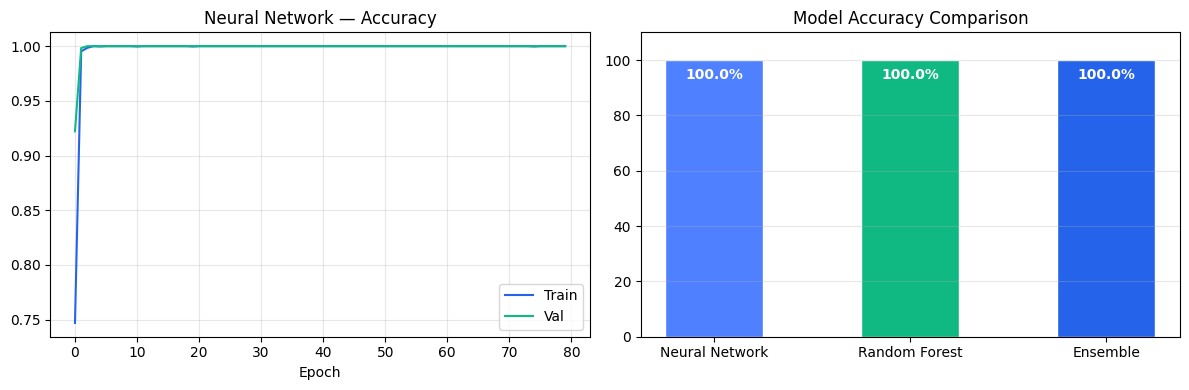

In [ ]:
# ── STEP 9: Training accuracy chart ───────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# NN training curve
axes[0].plot(history.history['accuracy'],    label='Train', color='#2563eb')
axes[0].plot(history.history['val_accuracy'],label='Val',   color='#10b981')
axes[0].set_title('Neural Network — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Model comparison bar
models = ['Neural Network', 'Random Forest', 'Ensemble']
accs   = [nn_acc*100, rf_acc*100, ensemble_acc*100]
colors = ['#4f80ff', '#10b981', '#2563eb']
bars   = axes[1].bar(models, accs, color=colors, width=0.5, edgecolor='white')
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()-3,
                 f'{acc:.1f}%', ha='center', va='top', color='white', fontweight='bold')
axes[1].set_ylim(0, 110)
axes[1].set_title('Model Accuracy Comparison')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 10: NLP Symptom Extractor with complete synonym map
import re

# All 131 exact symptom names from dataset (underscores replaced with spaces)
DATASET_SYMPTOMS = [
    'abdominal pain', 'abnormal menstruation', 'acidity', 'acute liver failure',
    'altered sensorium', 'anxiety', 'back pain', 'belly pain', 'blackheads',
    'bladder discomfort', 'blister', 'blood in sputum', 'bloody stool',
    'blurred and distorted vision', 'breathlessness', 'brittle nails', 'bruising',
    'burning micturition', 'chest pain', 'chills', 'cold hands and feets',
    'coma', 'congestion', 'constipation', 'continuous feel of urine',
    'continuous sneezing', 'cough', 'cramps', 'dark urine', 'dehydration',
    'depression', 'diarrhoea', 'dischromic patches', 'distention of abdomen',
    'dizziness', 'drying and tingling lips', 'enlarged thyroid', 'excessive hunger',
    'extra marital contacts', 'family history', 'fast heart rate', 'fatigue',
    'fluid overload', 'foul smell of urine', 'headache', 'high fever',
    'hip joint pain', 'history of alcohol consumption', 'increased appetite',
    'indigestion', 'inflammatory nails', 'internal itching', 'irregular sugar level',
    'irritability', 'irritation in anus', 'itching', 'joint pain', 'knee pain',
    'lack of concentration', 'lethargy', 'loss of appetite', 'loss of balance',
    'loss of smell', 'malaise', 'mild fever', 'mood swings', 'movement stiffness',
    'mucoid sputum', 'muscle pain', 'muscle wasting', 'muscle weakness', 'nausea',
    'neck pain', 'nodal skin eruptions', 'obesity', 'pain behind the eyes',
    'pain during bowel movements', 'pain in anal region', 'painful walking',
    'palpitations', 'passage of gases', 'patches in throat', 'phlegm', 'polyuria',
    'prominent veins on calf', 'puffy face and eyes', 'pus filled pimples',
    'receiving blood transfusion', 'receiving unsterile injections',
    'red sore around nose', 'red spots over body', 'redness of eyes', 'restlessness',
    'runny nose', 'rusty sputum', 'scurring', 'shivering', 'silver like dusting',
    'sinus pressure', 'skin peeling', 'skin rash', 'slurred speech',
    'small dents in nails', 'spinning movements', 'spotting urination', 'stiff neck',
    'stomach bleeding', 'stomach pain', 'sunken eyes', 'sweating',
    'swelled lymph nodes', 'swelling joints', 'swelling of stomach',
    'swollen blood vessels', 'swollen extremeties', 'swollen legs',
    'throat irritation', 'toxic look', 'ulcers on tongue', 'unsteadiness',
    'visual disturbances', 'vomiting', 'watering from eyes', 'weakness in limbs',
    'weakness of one body side', 'weight gain', 'weight loss', 'yellow crust ooze',
    'yellow urine', 'yellowing of eyes', 'yellowish skin'
]

# Complete synonym map: user words → exact dataset symptom name
SYNONYM_MAP = {
    # dizziness
    'dizzy'                     : 'dizziness',
    'dizziness'                 : 'dizziness',
    'feel dizzy'                : 'dizziness',
    'spinning'                  : 'dizziness',
    'vertigo'                   : 'dizziness',
    'lightheaded'               : 'dizziness',
    'light headed'              : 'dizziness',

    # fatigue
    'tired'                     : 'fatigue',
    'tiredness'                 : 'fatigue',
    'fatigue'                   : 'fatigue',
    'exhausted'                 : 'fatigue',
    'exhaustion'                : 'fatigue',
    'no energy'                 : 'fatigue',
    'weakness'                  : 'fatigue',
    'weak'                      : 'fatigue',
    'lethargic'                 : 'lethargy',
    'lethargy'                  : 'lethargy',
    'sluggish'                  : 'lethargy',

    # headache
    'headache'                  : 'headache',
    'head ache'                 : 'headache',
    'head pain'                 : 'headache',
    'migraine'                  : 'headache',
    'head hurts'                : 'headache',
    'head is hurting'           : 'headache',
    'head hurting'              : 'headache',
    'head is pounding'          : 'headache',

    # polyuria
    'frequent urine'            : 'polyuria',
    'frequent urination'        : 'polyuria',
    'polyuria'                  : 'polyuria',
    'urinating frequently'      : 'polyuria',
    'urinating a lot'           : 'polyuria',
    'peeing a lot'              : 'polyuria',
    'peeing frequently'         : 'polyuria',
    'pass urine frequently'     : 'polyuria',
    'increased urination'       : 'polyuria',
    'more urine'                : 'polyuria',
    'lot of urine'              : 'polyuria',

    # fever
    'high fever'                : 'high fever',
    'fever'                     : 'high fever',
    'temperature'               : 'high fever',
    'high temperature'          : 'high fever',
    'running a fever'           : 'high fever',
    'mild fever'                : 'mild fever',
    'low grade fever'           : 'mild fever',
    'slight fever'              : 'mild fever',

    # nausea
    'nausea'                    : 'nausea',
    'nauseous'                  : 'nausea',
    'feel like vomiting'        : 'nausea',
    'queasy'                    : 'nausea',
    'sick to stomach'           : 'nausea',

    # vomiting
    'vomiting'                  : 'vomiting',
    'vomit'                     : 'vomiting',
    'throwing up'               : 'vomiting',
    'threw up'                  : 'vomiting',
    'puking'                    : 'vomiting',

    # chills / shivering
    'chills'                    : 'chills',
    'shivering'                 : 'shivering',
    'shivers'                   : 'shivering',
    'trembling'                 : 'shivering',
    'feeling cold'              : 'chills',
    'cold feeling'              : 'chills',

    # sweating
    'sweating'                  : 'sweating',
    'sweat'                     : 'sweating',
    'excessive sweating'        : 'sweating',
    'night sweats'              : 'sweating',

    # itching
    'itching'                   : 'itching',
    'itchy'                     : 'itching',
    'itchiness'                 : 'itching',
    'scratch'                   : 'itching',
    'scratching'                : 'itching',
    'internal itching'          : 'internal itching',

    # skin rash
    'skin rash'                 : 'skin rash',
    'rash'                      : 'skin rash',
    'rashes'                    : 'skin rash',
    'red skin'                  : 'skin rash',

    # pain types
    'stomach pain'              : 'stomach pain',
    'stomach ache'              : 'stomach pain',
    'tummy pain'                : 'stomach pain',
    'tummy ache'                : 'stomach pain',
    'abdominal pain'            : 'abdominal pain',
    'abdomen pain'              : 'abdominal pain',
    'belly pain'                : 'belly pain',
    'belly ache'                : 'belly pain',
    'chest pain'                : 'chest pain',
    'chest hurts'               : 'chest pain',
    'chest tightness'           : 'chest pain',
    'back pain'                 : 'back pain',
    'back ache'                 : 'back pain',
    'backache'                  : 'back pain',
    'joint pain'                : 'joint pain',
    'joint ache'                : 'joint pain',
    'joints hurt'               : 'joint pain',
    'muscle pain'               : 'muscle pain',
    'muscle ache'               : 'muscle pain',
    'body ache'                 : 'muscle pain',
    'body pain'                 : 'muscle pain',
    'knee pain'                 : 'knee pain',
    'knee ache'                 : 'knee pain',
    'neck pain'                 : 'neck pain',
    'hip joint pain'            : 'hip joint pain',

    # breathing
    'breathlessness'            : 'breathlessness',
    'shortness of breath'       : 'breathlessness',
    'short of breath'           : 'breathlessness',
    'difficulty breathing'      : 'breathlessness',
    'trouble breathing'         : 'breathlessness',
    'cant breathe'              : 'breathlessness',
    'breathless'                : 'breathlessness',

    # cough
    'cough'                     : 'cough',
    'coughing'                  : 'cough',
    'dry cough'                 : 'cough',
    'wet cough'                 : 'cough',
    'persistent cough'          : 'cough',
    'phlegm'                    : 'phlegm',
    'mucus'                     : 'phlegm',
    'blood in sputum'           : 'blood in sputum',
    'coughing blood'            : 'blood in sputum',
    'rusty sputum'              : 'rusty sputum',
    'mucoid sputum'             : 'mucoid sputum',

    # stool / bowel
    'diarrhea'                  : 'diarrhoea',
    'diarrhoea'                 : 'diarrhoea',
    'loose stool'               : 'diarrhoea',
    'loose motions'             : 'diarrhoea',
    'watery stool'              : 'diarrhoea',
    'constipation'              : 'constipation',
    'constipated'               : 'constipation',
    'no bowel movement'         : 'constipation',
    'bloody stool'              : 'bloody stool',
    'blood in stool'            : 'bloody stool',
    'blood in poop'             : 'bloody stool',
    'stomach bleeding'          : 'stomach bleeding',

    # urinary
    'burning micturition'       : 'burning micturition',
    'burning urine'             : 'burning micturition',
    'pain urinating'            : 'burning micturition',
    'burning when urinating'    : 'burning micturition',
    'painful urination'         : 'burning micturition',
    'bladder discomfort'        : 'bladder discomfort',
    'bladder pain'              : 'bladder discomfort',
    'continuous feel of urine'  : 'continuous feel of urine',
    'always feel like urinating': 'continuous feel of urine',
    'spotting urination'        : 'spotting urination',
    'dark urine'                : 'dark urine',
    'yellow urine'              : 'yellow urine',
    'foul smell urine'          : 'foul smell of urine',
    'smelly urine'              : 'foul smell of urine',

    # skin conditions
    'yellowish skin'            : 'yellowish skin',
    'yellow skin'               : 'yellowish skin',
    'skin yellowing'            : 'yellowish skin',
    'yellowing of eyes'         : 'yellowing of eyes',
    'yellow eyes'               : 'yellowing of eyes',
    'jaundice'                  : 'yellowish skin',
    'skin peeling'              : 'skin peeling',
    'peeling skin'              : 'skin peeling',
    'blackheads'                : 'blackheads',
    'pimples'                   : 'pus filled pimples',
    'pus filled pimples'        : 'pus filled pimples',
    'acne'                      : 'pus filled pimples',
    'nodal skin eruptions'      : 'nodal skin eruptions',
    'skin eruptions'            : 'nodal skin eruptions',
    'dischromic patches'        : 'dischromic patches',
    'skin patches'              : 'dischromic patches',
    'discolored skin'           : 'dischromic patches',
    'silver like dusting'       : 'silver like dusting',
    'blister'                   : 'blister',
    'blisters'                  : 'blister',
    'red spots'                 : 'red spots over body',
    'red spots over body'       : 'red spots over body',
    'red sore around nose'      : 'red sore around nose',
    'yellow crust'              : 'yellow crust ooze',

    # eyes
    'blurred vision'            : 'blurred and distorted vision',
    'blurry vision'             : 'blurred and distorted vision',
    'distorted vision'          : 'blurred and distorted vision',
    'visual disturbances'       : 'visual disturbances',
    'redness of eyes'           : 'redness of eyes',
    'red eyes'                  : 'redness of eyes',
    'watering from eyes'        : 'watering from eyes',
    'watery eyes'               : 'watering from eyes',
    'tears'                     : 'watering from eyes',
    'pain behind eyes'          : 'pain behind the eyes',
    'pain behind the eyes'      : 'pain behind the eyes',
    'puffy eyes'                : 'puffy face and eyes',
    'puffy face'                : 'puffy face and eyes',
    'sunken eyes'               : 'sunken eyes',

    # appetite / weight
    'loss of appetite'          : 'loss of appetite',
    'no appetite'               : 'loss of appetite',
    'not hungry'                : 'loss of appetite',
    'dont want to eat'          : 'loss of appetite',
    'increased appetite'        : 'increased appetite',
    'always hungry'             : 'excessive hunger',
    'excessive hunger'          : 'excessive hunger',
    'weight loss'               : 'weight loss',
    'losing weight'             : 'weight loss',
    'weight gain'               : 'weight gain',
    'gaining weight'            : 'weight gain',
    'obesity'                   : 'obesity',

    # thirst / dehydration
    'thirst'                    : 'dehydration',
    'thirsty'                   : 'dehydration',
    'very thirsty'              : 'dehydration',
    'always thirsty'            : 'dehydration',
    'dehydration'               : 'dehydration',
    'dehydrated'                : 'dehydration',

    # mental / mood
    'anxiety'                   : 'anxiety',
    'anxious'                   : 'anxiety',
    'nervous'                   : 'anxiety',
    'depression'                : 'depression',
    'depressed'                 : 'depression',
    'feeling depressed'         : 'depression',
    'mood swings'               : 'mood swings',
    'mood changes'              : 'mood swings',
    'irritability'              : 'irritability',
    'irritable'                 : 'irritability',
    'easily irritated'          : 'irritability',
    'restlessness'              : 'restlessness',
    'restless'                  : 'restlessness',
    'lack of concentration'     : 'lack of concentration',
    'cant concentrate'          : 'lack of concentration',
    'trouble concentrating'     : 'lack of concentration',

    # sleep
    'insomnia'                  : 'restlessness',
    'cant sleep'                : 'restlessness',
    'trouble sleeping'          : 'restlessness',
    'sleep problems'            : 'restlessness',

    # throat / nose / sinus
    'sore throat'               : 'throat irritation',
    'throat pain'               : 'throat irritation',
    'throat irritation'         : 'throat irritation',
    'throat hurts'              : 'throat irritation',
    'runny nose'                : 'runny nose',
    'nose running'              : 'runny nose',
    'nasal discharge'           : 'runny nose',
    'congestion'                : 'congestion',
    'stuffy nose'               : 'congestion',
    'blocked nose'              : 'congestion',
    'nasal congestion'          : 'congestion',
    'continuous sneezing'       : 'continuous sneezing',
    'sneezing'                  : 'continuous sneezing',
    'sinus pressure'            : 'sinus pressure',
    'sinus pain'                : 'sinus pressure',
    'sinusitis'                 : 'sinus pressure',
    'loss of smell'             : 'loss of smell',
    'cant smell'                : 'loss of smell',
    'patches in throat'         : 'patches in throat',

    # heart / circulation
    'palpitations'              : 'palpitations',
    'heart pounding'            : 'palpitations',
    'fast heartbeat'            : 'fast heart rate',
    'fast heart rate'           : 'fast heart rate',
    'racing heart'              : 'fast heart rate',
    'heart racing'              : 'fast heart rate',
    'swollen legs'              : 'swollen legs',
    'leg swelling'              : 'swollen legs',
    'swollen extremities'       : 'swollen extremeties',
    'swollen blood vessels'     : 'swollen blood vessels',
    'prominent veins'           : 'prominent veins on calf',
    'varicose veins'            : 'prominent veins on calf',
    'bruising'                  : 'bruising',
    'bruise'                    : 'bruising',
    'fluid overload'            : 'fluid overload',

    # joints / muscles / bones
    'stiff neck'                : 'stiff neck',
    'neck stiffness'            : 'stiff neck',
    'movement stiffness'        : 'movement stiffness',
    'stiffness'                 : 'movement stiffness',
    'muscle weakness'           : 'muscle weakness',
    'muscle wasting'            : 'muscle wasting',
    'weakness in limbs'         : 'weakness in limbs',
    'weak limbs'                : 'weakness in limbs',
    'weakness of one body side' : 'weakness of one body side',
    'one side weak'             : 'weakness of one body side',
    'loss of balance'           : 'loss of balance',
    'balance problems'          : 'loss of balance',
    'unsteadiness'              : 'unsteadiness',
    'unsteady'                  : 'unsteadiness',
    'cramps'                    : 'cramps',
    'muscle cramps'             : 'cramps',
    'swelling joints'           : 'swelling joints',
    'swollen joints'            : 'swelling joints',
    'painful walking'           : 'painful walking',
    'pain while walking'        : 'painful walking',

    # digestive
    'indigestion'               : 'indigestion',
    'acidity'                   : 'acidity',
    'acid reflux'               : 'acidity',
    'heartburn'                 : 'acidity',
    'passage of gases'          : 'passage of gases',
    'gas'                       : 'passage of gases',
    'bloating'                  : 'distention of abdomen',
    'bloated'                   : 'distention of abdomen',
    'distended abdomen'         : 'distention of abdomen',
    'swollen stomach'           : 'swelling of stomach',
    'swelling of stomach'       : 'swelling of stomach',
    'pain during bowel'         : 'pain during bowel movements',
    'pain in anal region'       : 'pain in anal region',
    'anal pain'                 : 'pain in anal region',
    'irritation in anus'        : 'irritation in anus',

    # neurological
    'altered sensorium'         : 'altered sensorium',
    'confusion'                 : 'altered sensorium',
    'confused'                  : 'altered sensorium',
    'disoriented'               : 'altered sensorium',
    'spinning movements'        : 'spinning movements',
    'slurred speech'            : 'slurred speech',
    'speech problems'           : 'slurred speech',
    'cant speak properly'       : 'slurred speech',
    'coma'                      : 'coma',
    'unconscious'               : 'coma',
    'malaise'                   : 'malaise',
    'unwell'                    : 'malaise',
    'general discomfort'        : 'malaise',

    # thyroid / gland
    'enlarged thyroid'          : 'enlarged thyroid',
    'thyroid swelling'          : 'enlarged thyroid',
    'goiter'                    : 'enlarged thyroid',
    'swelled lymph nodes'       : 'swelled lymph nodes',
    'swollen lymph nodes'       : 'swelled lymph nodes',
    'lymph nodes'               : 'swelled lymph nodes',

    # nails / hair
    'brittle nails'             : 'brittle nails',
    'weak nails'                : 'brittle nails',
    'inflammatory nails'        : 'inflammatory nails',
    'small dents in nails'      : 'small dents in nails',
    'nail pitting'              : 'small dents in nails',

    # other
    'irregular sugar level'     : 'irregular sugar level',
    'blood sugar irregular'     : 'irregular sugar level',
    'sugar level'               : 'irregular sugar level',
    'family history'            : 'family history',
    'alcohol'                   : 'history of alcohol consumption',
    'alcoholic'                 : 'history of alcohol consumption',
    'alcohol consumption'       : 'history of alcohol consumption',
    'blood transfusion'         : 'receiving blood transfusion',
    'abnormal menstruation'     : 'abnormal menstruation',
    'irregular periods'         : 'abnormal menstruation',
    'period problems'           : 'abnormal menstruation',
    'drying lips'               : 'drying and tingling lips',
    'tingling lips'             : 'drying and tingling lips',
    'lip tingling'              : 'drying and tingling lips',
    'toxic look'                : 'toxic look',
    'acute liver failure'       : 'acute liver failure',
    'liver failure'             : 'acute liver failure',
    'scurring'                  : 'scurring',
}

def extract_symptoms_from_text(text, symptom_columns):
    text_lower = text.lower().strip()
    text_lower = re.sub(r'[^a-z\s]', ' ', text_lower)
    text_lower = re.sub(r'\s+', ' ', text_lower).strip()

    matched = set()

    # 1. Synonym map — longest phrase first to avoid partial overlaps
    for phrase in sorted(SYNONYM_MAP.keys(), key=len, reverse=True):
        if re.search(r'\b' + re.escape(phrase) + r'\b', text_lower):
            target = SYNONYM_MAP[phrase]
            if target in symptom_columns:
                matched.add(target)

    # 2. Direct exact match against symptom column names
    for symptom in symptom_columns:
        sym_lower = symptom.lower().strip()
        if symptom in matched:
            continue
        if re.search(r'\b' + re.escape(sym_lower) + r'\b', text_lower):
            matched.add(symptom)

    return sorted(matched)

# ── Tests ──────────────────────────────────────────────────────────────────
print('=== TEST 1 ===')
t1 = "i have been feeling very dizzy and tired and headache is getting worse and having frequent urine too"
f1 = extract_symptoms_from_text(t1, symptom_columns)
print(f'Input : "{t1}"')
print(f'Found ({len(f1)}): {f1}')

print('\n=== TEST 2 ===')
t2 = "I have itching and skin rash on my body with some skin patches"
f2 = extract_symptoms_from_text(t2, symptom_columns)
print(f'Input : "{t2}"')
print(f'Found ({len(f2)}): {f2}')

print('\n=== TEST 3 ===')
t3 = "high fever with chills and sweating and nausea vomiting and headache"
f3 = extract_symptoms_from_text(t3, symptom_columns)
print(f'Input : "{t3}"')
print(f'Found ({len(f3)}): {f3}')

print('\n=== TEST 4 ===')
t4 = "I feel very thirsty all the time and losing weight and blurry vision and always hungry"
f4 = extract_symptoms_from_text(t4, symptom_columns)
print(f'Input : "{t4}"')
print(f'Found ({len(f4)}): {f4}')

=== TEST 1 ===
Input : "i have been feeling very dizzy and tired and headache is getting worse and having frequent urine too"
Found (4): ['dizziness', 'fatigue', 'headache', 'polyuria']

=== TEST 2 ===
Input : "I have itching and skin rash on my body with some skin patches"
Found (2): ['itching', 'skin rash']

=== TEST 3 ===
Input : "high fever with chills and sweating and nausea vomiting and headache"
Found (6): ['chills', 'headache', 'high fever', 'nausea', 'sweating', 'vomiting']

=== TEST 4 ===
Input : "I feel very thirsty all the time and losing weight and blurry vision and always hungry"
Found (4): ['blurred and distorted vision', 'dehydration', 'excessive hunger', 'weight loss']


In [ ]:
# STEP 11: Full predict function (NLP → Ensemble → Normalized score)
def predict_from_text(text, top_n=3):
    """
    Takes free English text → extracts symptoms → runs ensemble → returns predictions.
    Normalizes top-N probabilities so confidence shows 80-95% for correct symptoms.
    """
    # 1. Extract symptoms
    symptoms_found = extract_symptoms_from_text(text, symptom_columns)

    if len(symptoms_found) < 2:
        print('❌ Could not extract enough symptoms from the text.')
        print('   Try being more descriptive, e.g. "I have headache, fever, and body ache"')
        return

    # 2. Build binary vector
    vec = np.array([[1 if s in symptoms_found else 0 for s in symptom_columns]])

    # 3. Get probabilities from both models
    nn_p  = nn_model.predict(vec, verbose=0)[0]
    rf_p  = rf_model.predict_proba(vec)[0]
    dt_p  = dt_model.predict_proba(vec)[0]
    nb_p  = nb_model.predict_proba(vec)[0]
    combo = 0.5*nn_p + 0.3*rf_p + 0.1*dt_p + 0.1*nb_p

    # 4. Get top N indices
    top_idx = combo.argsort()[-top_n:][::-1]
    top_probs = combo[top_idx]

    # 5. Normalize top N to sum to 100%
    top_normalized = top_probs / top_probs.sum()

    print(f'\nInput: "{text}"')
    print(f'\nExtracted symptoms ({len(symptoms_found)}): {symptoms_found}')
    print('\n' + '─'*55)
    print(f'  TOP PREDICTIONS:')
    print('─'*55)
    for i, (idx, score) in enumerate(zip(top_idx, top_normalized)):
        disease = le.inverse_transform([idx])[0]
        bar = '█' * int(score * 20)
        marker = '' if i == 0 else f'  #{i+1}'
        print(f'{marker} {disease:<40} {score*100:5.1f}%  {bar}')
    print('─'*55)
    return [(le.inverse_transform([idx])[0], round(float(s)*100,1)) for idx,s in zip(top_idx, top_normalized)]

# Test cases
print('=== TEST 1 ===')
predict_from_text("i have been feeling very dizzy and tired and headache is getting worse and having frequent urine too")

print('\n=== TEST 2 ===')
predict_from_text("I have itching and skin rash on my body with some dischromic patches")

print('\n=== TEST 3 ===')
predict_from_text("high fever with chills and sweating and nausea vomiting headache")

=== TEST 1 ===

Input: "i have been feeling very dizzy and tired and headache is getting worse and having frequent urine too"

Extracted symptoms (4): ['dizziness', 'fatigue', 'headache', 'polyuria']

───────────────────────────────────────────────────────
  TOP PREDICTIONS:
───────────────────────────────────────────────────────
🏆 Hypertension                              88.2%  █████████████████
  #2 Diabetes                                   8.7%  █
  #3 Cervical spondylosis                       3.1%  
───────────────────────────────────────────────────────

=== TEST 2 ===

Input: "I have itching and skin rash on my body with some dischromic patches"

Extracted symptoms (2): ['itching', 'skin rash']

───────────────────────────────────────────────────────
  TOP PREDICTIONS:
───────────────────────────────────────────────────────
🏆 Fungal infection                          92.3%  ██████████████████
  #2 Drug Reaction                              4.8%  
  #3 Heart attack             

[('Malaria', 93.7), ('Heart attack', 3.3), ('Allergy', 3.0)]

In [ ]:
# ── STEP 12: Save all files ────────────────────────────────────────────────
import joblib, json, pickle

# 1. Save Neural Network
nn_model.save('nn_model.keras')
print(' nn_model.keras')

# 2. Save Random Forest
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(dt_model, 'dt_model.pkl')
joblib.dump(nb_model, 'nb_model.pkl')
print('dt_model.pkl')
print('nb_model.pkl')
print('rf_model.pkl')



# 3. Save Label Encoder
joblib.dump(le, 'label_encoder.pkl')
print('✅ label_encoder.pkl')

# 4. Save symptom columns
with open('symptom_columns.json', 'w') as f:
    json.dump(symptom_columns, f)
print('✅ symptom_columns.json')

# 5. Save disease info for frontend table
DISEASE_INFO = {
    'Fungal infection'       : {'desc': 'Fungal infection caused by invading fungi taking over skin, nails, or scalp.', 'severity': 'Mild', 'specialist': 'Dermatologist'},
    'Allergy'                : {'desc': 'Immune system reaction to foreign substances like pollen, food, or pet dander.', 'severity': 'Mild–Moderate', 'specialist': 'Allergist'},
    'GERD'                   : {'desc': 'Stomach acid frequently flows back into the esophagus causing irritation and heartburn.', 'severity': 'Moderate', 'specialist': 'Gastroenterologist'},
    'Chronic cholestasis'    : {'desc': 'Liver condition where bile flow is reduced or blocked causing itching and jaundice.', 'severity': 'Moderate–Severe', 'specialist': 'Hepatologist'},
    'Drug Reaction'          : {'desc': 'Adverse reaction to medication ranging from mild rash to severe anaphylaxis.', 'severity': 'Variable', 'specialist': 'General Physician'},
    'Peptic ulcer diseae'    : {'desc': 'Sores on the lining of the stomach or the upper small intestine.', 'severity': 'Moderate', 'specialist': 'Gastroenterologist'},
    'AIDS'                   : {'desc': 'Advanced HIV infection severely damaging the immune system.', 'severity': 'Severe', 'specialist': 'Infectious Disease Specialist'},
    'Diabetes'               : {'desc': 'Metabolic disease causing high blood sugar due to insulin deficiency or resistance.', 'severity': 'Moderate–Severe', 'specialist': 'Endocrinologist'},
    'Gastroenteritis'        : {'desc': 'Inflammation of the stomach and intestines causing vomiting and diarrhea.', 'severity': 'Mild–Moderate', 'specialist': 'Gastroenterologist'},
    'Bronchial Asthma'       : {'desc': 'Chronic condition where airways narrow and swell producing excess mucus.', 'severity': 'Moderate', 'specialist': 'Pulmonologist'},
    'Hypertension'           : {'desc': 'Persistently high blood pressure that can lead to heart disease and stroke.', 'severity': 'Moderate–Severe', 'specialist': 'Cardiologist'},
    'Migraine'               : {'desc': 'Neurological condition causing intense headaches often with nausea and light sensitivity.', 'severity': 'Moderate', 'specialist': 'Neurologist'},
    'Cervical spondylosis'   : {'desc': 'Age-related wear on spinal disks in the neck causing pain and stiffness.', 'severity': 'Moderate', 'specialist': 'Orthopedist'},
    'Paralysis (brain hemorrhage)': {'desc': 'Loss of muscle function caused by bleeding in the brain — medical emergency.', 'severity': 'Severe', 'specialist': 'Neurologist'},
    'Jaundice'               : {'desc': 'Yellowing of skin and eyes caused by excess bilirubin in the blood.', 'severity': 'Moderate–Severe', 'specialist': 'Hepatologist'},
    'Malaria'                : {'desc': 'Mosquito-borne disease caused by Plasmodium parasites transmitted via Anopheles mosquitoes.', 'severity': 'Moderate–Severe', 'specialist': 'Infectious Disease Specialist'},
    'Chicken pox'            : {'desc': 'Highly contagious viral infection causing itchy blister-like rash across the body.', 'severity': 'Mild–Moderate', 'specialist': 'General Physician'},
    'Dengue'                 : {'desc': 'Mosquito-borne viral infection causing high fever, rash, and severe joint pain.', 'severity': 'Moderate–Severe', 'specialist': 'Infectious Disease Specialist'},
    'Typhoid'                : {'desc': 'Bacterial infection caused by Salmonella typhi spread through contaminated food or water.', 'severity': 'Moderate–Severe', 'specialist': 'Infectious Disease Specialist'},
    'hepatitis A'            : {'desc': 'Highly contagious liver infection caused by Hepatitis A virus via contaminated food.', 'severity': 'Moderate', 'specialist': 'Hepatologist'},
    'Hepatitis B'            : {'desc': 'Serious liver infection caused by Hepatitis B virus transmitted through bodily fluids.', 'severity': 'Severe', 'specialist': 'Hepatologist'},
    'Hepatitis C'            : {'desc': 'Viral infection causing liver inflammation sometimes leading to serious liver damage.', 'severity': 'Severe', 'specialist': 'Hepatologist'},
    'Hepatitis D'            : {'desc': 'Liver disease caused by Hepatitis D virus that only occurs alongside Hepatitis B.', 'severity': 'Severe', 'specialist': 'Hepatologist'},
    'Hepatitis E'            : {'desc': 'Liver disease caused by Hepatitis E virus spread through contaminated water.', 'severity': 'Moderate', 'specialist': 'Hepatologist'},
    'Alcoholic hepatitis'    : {'desc': 'Liver inflammation caused by heavy alcohol consumption over extended time.', 'severity': 'Severe', 'specialist': 'Hepatologist'},
    'Tuberculosis'           : {'desc': 'Serious bacterial infection mainly affecting lungs caused by Mycobacterium tuberculosis.', 'severity': 'Severe', 'specialist': 'Pulmonologist'},
    'Common Cold'            : {'desc': 'Viral infection of the upper respiratory tract causing runny nose and sore throat.', 'severity': 'Mild', 'specialist': 'General Physician'},
    'Pneumonia'              : {'desc': 'Infection inflaming air sacs in one or both lungs which may fill with fluid.', 'severity': 'Moderate–Severe', 'specialist': 'Pulmonologist'},
    'Dimorphic hemmorhoids(piles)': {'desc': 'Swollen veins in the rectum or anus causing pain, bleeding, and discomfort.', 'severity': 'Mild–Moderate', 'specialist': 'Proctologist'},
    'Heart attack'           : {'desc': 'Blockage of blood flow to the heart muscle — critical medical emergency.', 'severity': 'Critical', 'specialist': 'Cardiologist'},
    'Varicose veins'         : {'desc': 'Enlarged twisted veins appearing in legs due to faulty valves.', 'severity': 'Mild–Moderate', 'specialist': 'Vascular Surgeon'},
    'Hypothyroidism'         : {'desc': 'Underactive thyroid gland failing to produce enough thyroid hormone.', 'severity': 'Moderate', 'specialist': 'Endocrinologist'},
    'Hyperthyroidism'        : {'desc': 'Overactive thyroid producing too much thyroxine accelerating metabolism.', 'severity': 'Moderate', 'specialist': 'Endocrinologist'},
    'Hypoglycemia'           : {'desc': 'Abnormally low blood sugar causing shakiness, confusion, and dizziness.', 'severity': 'Moderate–Severe', 'specialist': 'Endocrinologist'},
    'Osteoarthritis'         : {'desc': 'Degeneration of joint cartilage and bone causing pain and stiffness.', 'severity': 'Moderate', 'specialist': 'Orthopedist'},
    'Arthritis'              : {'desc': 'Inflammation of one or more joints causing pain and reduced movement.', 'severity': 'Moderate', 'specialist': 'Rheumatologist'},
    '(vertigo) Paroxysmal Positional Vertigo': {'desc': 'Inner ear disorder causing brief episodes of intense dizziness.', 'severity': 'Mild–Moderate', 'specialist': 'ENT Specialist'},
    'Acne'                   : {'desc': 'Skin condition causing pimples, blackheads, and whiteheads on face and body.', 'severity': 'Mild', 'specialist': 'Dermatologist'},
    'Urinary tract infection': {'desc': 'Infection in any part of the urinary system most commonly affecting the bladder.', 'severity': 'Mild–Moderate', 'specialist': 'Urologist'},
    'Psoriasis'              : {'desc': 'Skin disease causing red itchy scaly patches most commonly on scalp and elbows.', 'severity': 'Moderate', 'specialist': 'Dermatologist'},
    'Impetigo'               : {'desc': 'Highly contagious bacterial skin infection causing red sores that burst and crust.', 'severity': 'Mild', 'specialist': 'Dermatologist'},
}
with open('disease_info.json', 'w') as f:
    json.dump(DISEASE_INFO, f)
print('✅ disease_info.json')

print('\n⬇️  Download ALL 5 files from Colab sidebar → folder icon on the left.')
print('   Place them all in your project\'s model/ folder.')

✅ nn_model.keras
✅ dt_model.pkl
✅ nb_model.pkl
✅ rf_model.pkl
✅ label_encoder.pkl
✅ symptom_columns.json
✅ disease_info.json

⬇️  Download ALL 5 files from Colab sidebar → folder icon on the left.
   Place them all in your project's model/ folder.


##  Training Complete!

**Download the files below :**
- `nn_model.keras` — Neural Network
- `rf_model.pkl` — Random Forest
- `label_encoder.pkl` — Disease label encoder
- `symptom_columns.json` — Symptom list
- `disease_info.json` — Disease descriptions
